In [69]:
from operator import add
from typing import List, TypedDict, Optional, Annotated, Dict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

In [70]:
import getpass
import os

from pydantic import BaseModel, Json
from langgraph.checkpoint.sqlite import SqliteSaver

memory = SqliteSaver.from_conn_string(":memory:")

def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"Please provide your {var}")


_set_if_undefined("OPENAI_API_KEY")
_set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

# Optional, add tracing in LangSmith.
# This will help you visualize and debug the control flow
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Sales Research Agent"

from typing import Annotated, List
import operator

from langchain_community.document_loaders import WebBaseLoader
# from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

# tavily_tool = TavilySearchResults(max_results=5)

class ProfilePost(BaseModel):
    post:str
    postUrl: str
    likeCount:str
    postedDate: str


class UserProfile(BaseModel):

    username: str
    summary: str
    firstName:str
    lastName: str
    headline: str
    currentPos:str
    posts: List[ProfilePost]

class AgentState(TypedDict):
    linkedin_url:str
    website:str
    user_profile_details:Annotated[str,operator.add]
    scraped_website_content:Annotated[str, operator.add]
    user_profile_analysis: Annotated[str, operator.add]
    website_analysis: Annotated[str, operator.add]
    sales_research_report:Annotated[str,operator.add]

    # companyProfile: 

def collector(state:AgentState):
    print("WEBSITE COLLECTOR ", state["website"])
    return {"linkedin_url":state["linkedin_url"], "website":state["website"]}

#scrape webpages node
def scrape_webpages(state:AgentState) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    print("website " , state["website"])
    loader = WebBaseLoader(state["website"])

    docs = loader.load()
    print("docs", docs)
    scraped_content= "\n\n".join(
        [
            f'{doc.page_content}'
            for doc in docs
        ]
    )
    return {"scraped_website_content": scraped_content}

#analyze linked_in node
def get_linkedin_data(state: AgentState):
    """Used to analyze a linkedin user profile and create summary of profile posts etc"""

    import requests
    import json

    profile_url = "https://linkedin-api8.p.rapidapi.com/get-profile-data-by-url"
    

    querystring = {"url":state["linkedin_url"]}

    headers = {
        "x-rapidapi-key": "9958411ebcmsh66b1d9ce41707e2p1f8b93jsncb08b597fba0",
        "x-rapidapi-host": "linkedin-api8.p.rapidapi.com"
    }

    response = requests.get(profile_url, headers=headers, params=querystring)

    profile_details= response.json()

    print(response.json())

    posts_url = "https://linkedin-api8.p.rapidapi.com/get-profile-posts"

    querystring = {"username":profile_details["username"]}

    response = requests.get(posts_url, headers=headers, params=querystring)

    profile_posts= response.json()

    profile_posts= profile_posts["data"][:5] #get latest 3 posts

    # return profile data ans posts
    posts_dict={"posts":profile_posts}
    

    merged_json = merge_json(profile_details.copy(), posts_dict)

    return {"user_profile_details": json.dumps(merged_json)}

def merge_json(json1, json2):
    for key, value in json2.items():
        if key in json1 and isinstance(json1[key], dict) and isinstance(value, dict):
            merge_json(json1[key], value)
        else:
            json1[key] = value
    return json1

LINKEDIN_ANALYZER_PROMPT='''you are expert linkedin post analyser and you are tasked to analyze each linkedin profile and posts provided below and 
summarize in about 250 words and find patterns in the post. 
The number of summaries must match the number of posts provided.
For each post provide a summary of the post in this format
 """{ post_title:" ",      
        summary:" ",
        posted_date: "date"}"""
'''

def linkedin_profile_analyzer(state:AgentState):

    messages = [
        SystemMessage(content=LINKEDIN_ANALYZER_PROMPT), 
        HumanMessage(content=state['user_profile_details'])
    ]
    
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response = model.invoke(messages)
    return {"user_profile_analysis":response.content}

WEBSITE_ANALYZER_PROMPT='''you are an expert google search researcher in analyzing the scraped website content and
                         your are tasked to identify the details of the company from the website, such as industry, customers,
                        industry painpoints, their product or service offerings.
                        The output should be in a json format:
                        Example: {"summary":"",    "industry":"","painpoints":"","products/services":"" }  
                        ##IMPORTANT
                        If you cannot infer any of the the details mention them as not available, just don't make any assumptions.
                        Remember, your analysis should be based solely on the data provided for the scraped content. 
                        Please refrain from speculating or making assumptions. Your task is to provide factual and verifiable information.
                        '''

def website_analyzer(state: AgentState):
     
    messages = [
        SystemMessage(content=WEBSITE_ANALYZER_PROMPT), 
        HumanMessage(content=state['scraped_website_content'])
    ]
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response = model.invoke(messages)
    return {"website_analysis":response.content}
     

     
REPORT_GENERATOR_PROMPT='''
    you are expert analyzer agent specialized in creating sales research report that is used by 
    sales team to reach the potential prospects. you are tasked to create a comprehensive sales research report
    consisting of every aspect required for sales team. from the information you have in

    {content}
    
    

    Here is a sample report structure you need to create 

        """1. Executive Summary

        Objective: Brief overview of the report's purpose.

        Key Findings: High-level insights from the analysis.

        Next Steps: Summary of recommended actions, first linkedin connection message using the above information from website and their linkedin posts

        2. User Profile Analysis

        Personal Information:

        Name, title, and role within the company.

        LinkedIn profile summary, posts 

        Professional Background:

        Career history and notable achievements.

        Recent activity on LinkedIn (posts, articles, engagements).

        Network Insights:

        Mutual connections, professional groups, and shared interests.

        Pain Points and Needs:

        Inferred or explicitly stated challenges and goals.

        3. Company Overview

        Basic Information:

        Company name, industry, size, and location.

        Mission, vision, and core values.

        Product/Service Offerings:

        Overview of products or services offered.

        Unique selling propositions (USPs) and market differentiators.

        Company Structure:

        Key executives and decision-makers.

        Organizational structure and departments of interest.

        Recent Company News:

        Recent announcements, press releases, or news articles.

        Any notable events such as product launches, partnerships, or changes in leadership.

        Financial Overview:

        Revenue, profitability, and any available financial metrics.

        Recent funding rounds, investors, and intended use of funds.

        4. Industry and Market Analysis

        Industry Overview:

        Description of the industry and market dynamics.

        Current trends, opportunities, and challenges in the industry.

        Market Position:

        Company’s position within the industry.

        Major competitors and market share analysis.

        SWOT Analysis:

        Strengths, Weaknesses, Opportunities, and Threats for the company in its market.

        Regulatory Environment:

        Any relevant regulations or industry standards that may impact the company.

        5. Competitive Landscape

        Key Competitors:

        List and brief profiles of main competitors.

        Comparative Analysis:

        Comparison of product/service offerings, market strategies, and customer base.

        Market Positioning:

        How the company is positioned relative to its competitors (e.g., pricing, features, brand image).

        6. Customer Insights

        Target Audience:

        Description of the company’s typical customer segments.

        Customer Needs:

        Insights into customer pain points, desires, and needs.

        Customer Feedback:

        Summary of customer reviews, testimonials, or case studies.

        7. Recent Developments

        Technology and Innovation:

        Any recent technological developments or innovations by the company.

        Strategic Initiatives:

        New strategies, partnerships, or initiatives the company is pursuing.

        Market Movements:

        Any mergers, acquisitions, or market exits.

        8. Sales and Marketing Strategies

        Current Sales Strategies:

        Overview of the company’s existing sales tactics and channels.

        Marketing Campaigns:

        Summary of recent or ongoing marketing campaigns(if any)

        Partnerships and Alliances:

        Key partnerships that influence sales and marketing efforts.

        9. Engagement Strategy and Recommendations

        Tailored Outreach Suggestions:

        Specific suggestions for initial contact, messaging, and value propositions.

        Conversation Starters: 

        Topics or questions that resonate with the prospect’s current situation or industry trends.

        Proposed Solutions:

        Custom AI or automation solutions that address identified pain points or opportunities.

        Follow-Up Plan:

        Timeline and content for follow-up interactions."""  
        '''
def sales_research_report_generator(state:AgentState):
    
    user_profile_analysis= state['user_profile_analysis']
    website_analysis=state["website_analysis"]

    content = user_profile_analysis + " " + website_analysis 
    messages = [
        SystemMessage(content=REPORT_GENERATOR_PROMPT.format(content= content))
    ]

    llm= ChatOpenAI(model="gpt-4o-mini", temperature=0)

    response= llm.invoke(messages)

    return {"sales_research_report": response.content}


from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional

from typing_extensions import TypedDict

_TEMP_DIRECTORY = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_DIRECTORY.name)

from typing import List, Optional

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph, START



builder = StateGraph(AgentState)

# add nodes to the graph
builder.add_node("collector",collector)
builder.add_node("profile_fetcher", get_linkedin_data )
builder.add_node("website_scraper", scrape_webpages)
builder.add_node("linkedin_profile_analyzer", linkedin_profile_analyzer)
builder.add_node("website_analyzer",website_analyzer)
builder.add_node("report_generator",sales_research_report_generator)
builder.add_conditional_edges()

#set entry point
builder.set_entry_point("collector")

#add edges
builder.add_edge("collector","profile_fetcher" )
builder.add_edge("collector","website_scraper")
builder.add_edge("profile_fetcher", "linkedin_profile_analyzer")
builder.add_edge("website_scraper","website_analyzer")
builder.add_edge("linkedin_profile_analyzer","report_generator")
builder.add_edge("website_analyzer","report_generator")

graph= builder.compile(checkpointer=memory)

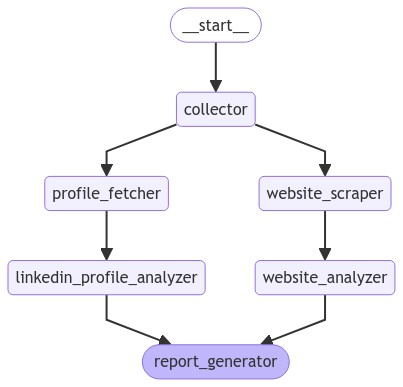

In [71]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [72]:
import uuid

In [73]:
thread = {"configurable": {"thread_id": uuid.uuid4}}
graph.invoke({
    "linkedin_url":"https://www.linkedin.com/in/benedek-zajkas-776b6b12a/",
    "website":""
},thread)

WEBSITE COLLECTOR  
website  
{'urn': 'ACoAAB_aGIoBCKm7tMkivJsm0GITihRwQ5v6Nuk', 'username': 'benedek-zajkas-776b6b12a', 'firstName': 'Benedek', 'lastName': 'Zajkas', 'isCreator': True, 'isOpenToWork': False, 'isHiring': False, 'profilePicture': 'https://media.licdn.com/dms/image/v2/C4D03AQHnkzk6S5Xl0Q/profile-displayphoto-shrink_800_800/profile-displayphoto-shrink_800_800/0/1658929292469?e=1729728000&v=beta&t=M_kwThJvDnAcI37chym2oX_fy842UvNszFyfsL2lruo', 'backgroundImage': [{'width': 800, 'height': 200, 'url': 'https://media.licdn.com/dms/image/v2/D4D16AQGgPTAhrQwWbg/profile-displaybackgroundimage-shrink_200_800/profile-displaybackgroundimage-shrink_200_800/0/1714119676378?e=1729728000&v=beta&t=-dACs-S5xGXiQxn7I_i15BVGn6ybqNVOrgHSuEeYNTg'}, {'width': 1400, 'height': 350, 'url': 'https://media.licdn.com/dms/image/v2/D4D16AQGgPTAhrQwWbg/profile-displaybackgroundimage-shrink_350_1400/profile-displaybackgroundimage-shrink_350_1400/0/1714119676378?e=1729728000&v=beta&t=toOuShqTjcNXrGWbjNjr

MissingSchema: Invalid URL '': No scheme supplied. Perhaps you meant https://?